# Image Processing – Cartoonization with U-GAT-IT

In this notebook, we use a U-GAT-IT-based image-to-image translation model to convert human selfie images into cartoon-style outputs.

We evaluate results across three fully trained model versions:

- **15K iterations** – early-stage generator  
- **50K iterations** – mid-stage generator  
- **100K iterations** – later-stage generator


### Research Question

> **How does training iteration count affect the quality and style of cartoonized outputs when transforming real human faces?**

Our goal is to assess how the visual quality and stylistic characteristics evolve with training. We evaluate the models qualitatively across:
- Facial fidelity and smoothness
- Color/texture stability
- Handling of lighting, background, and facial angle variance


## Environment Setup

We mount Google Drive to access input images, trained model checkpoints, and previously generated outputs.

**Mounting Drive**

In [1]:
# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


**Data Preparation**

In [ ]:
# Clone U-GAT-IT
!git clone https://github.com/znxlwm/UGATIT-pytorch /content/UGATIT

# Install dependencies
!pip install torch torchvision pillow matplotlib tqdm transformers gradio --quiet

Cloning into '/content/UGATIT'...
remote: Enumerating objects: 70, done.
remote: Total 70 (delta 0), reused 0 (delta 0), pack-reused 70 (from 1)
Receiving objects: 100% (70/70), 4.31 MiB | 18.80 MiB/s, done.
Resolving deltas: 100% (23/23), done.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 3.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 116.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 84.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 53.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 1.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 11.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 42.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 19.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 4.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

In [2]:
import os
os.makedirs("/content/drive/MyDrive/cartoonify/UGATIT/dataset/selfie2anime/testA", exist_ok=True)
os.makedirs("/content/drive/MyDrive/cartoonify/UGATIT/dataset/selfie2anime/testB", exist_ok=True)

In [3]:
from PIL import Image
import os

# Create a dummy white image
dummy = Image.new('RGB', (256, 256), color = 'white')

# Save into both testA and testB folders
os.makedirs("/content/UGATIT/dataset/selfie2anime/testA", exist_ok=True)
os.makedirs("/content/UGATIT/dataset/selfie2anime/testB", exist_ok=True)
dummy.save("/content/UGATIT/dataset/selfie2anime/testA/dummy.jpg")
dummy.save("/content/UGATIT/dataset/selfie2anime/testB/dummy.jpg")

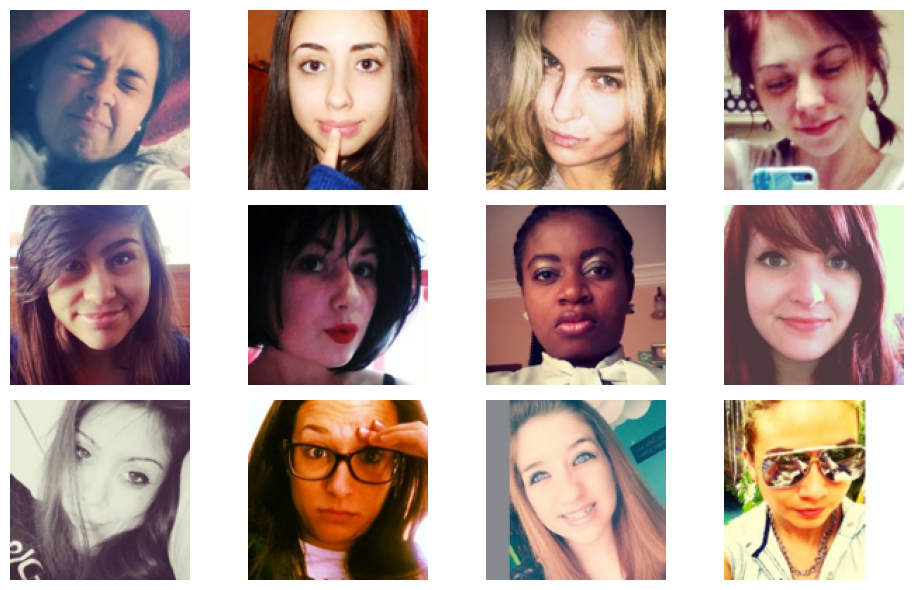

In [4]:
import os
import random
from PIL import Image as PILImage
import matplotlib.pyplot as plt

# Define the path
folder_path = '/content/drive/MyDrive/cartoonify/UGATIT/dataset/selfie2anime/trainA'

# List all image files and select 12 random ones
all_files = os.listdir(folder_path)
image_files = random.sample(all_files, 12)

# Set up grid size
num_images = len(image_files)
cols = 4
rows = (num_images + cols - 1) // cols

# Create the figure
plt.figure(figsize=(10, 6))

for i, file_name in enumerate(image_files):
    file_path = os.path.join(folder_path, file_name)
    img = PILImage.open(file_path).resize((128, 128))

    plt.subplot(rows, cols, i + 1)
    plt.imshow(img)
    plt.axis('off')

plt.tight_layout()
plt.show()

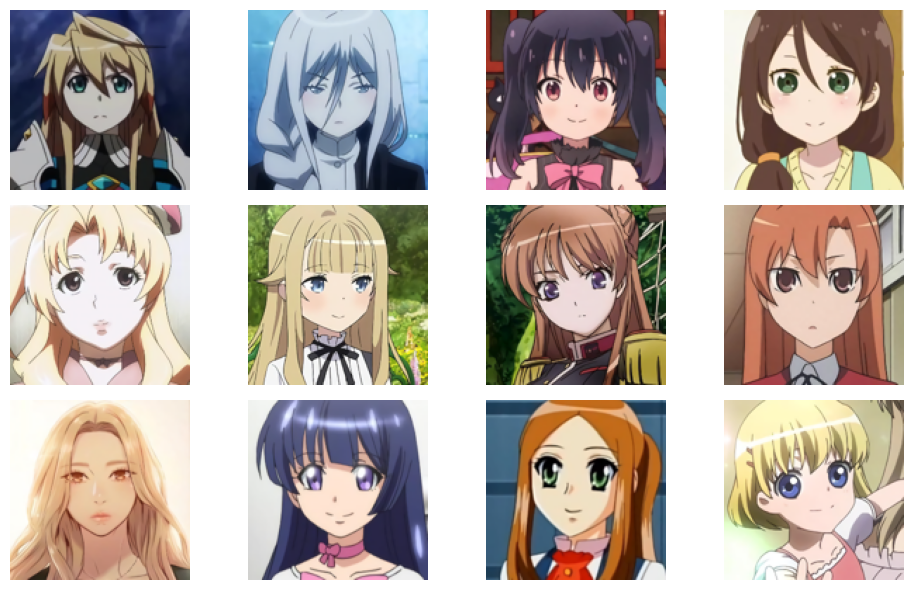

In [5]:
import os
import random
from PIL import Image as PILImage
import matplotlib.pyplot as plt

# Define the path
folder_path = '/content/drive/MyDrive/cartoonify/UGATIT/dataset/selfie2anime/trainB'

# List all image files and select 12 random ones
all_files = os.listdir(folder_path)
image_files = random.sample(all_files, 12)

# Set up grid size
num_images = len(image_files)
cols = 4
rows = (num_images + cols - 1) // cols

# Create the figure
plt.figure(figsize=(10, 6))

for i, file_name in enumerate(image_files):
    file_path = os.path.join(folder_path, file_name)
    img = PILImage.open(file_path).resize((128, 128))

    plt.subplot(rows, cols, i + 1)
    plt.imshow(img)
    plt.axis('off')

plt.tight_layout()
plt.show()

## Model Configuration and Inference Setup

We define configuration, attach a method to process one image at a time, and load the pretrained models.

In [2]:
!ls /content/drive/MyDrive/cartoonify/UGATIT/UGATIT.py

/content/drive/MyDrive/cartoonify/UGATIT/UGATIT.py


In [3]:
import os
os.chdir('/content/drive/MyDrive/cartoonify/UGATIT')


from UGATIT import UGATIT
from argparse import Namespace
import torch

In [6]:
# Choose which iteration we're working with
CURRENT_ITER = 15000  # or 50000, 100000

config = Namespace(
    dataset='selfie2anime',
    phase='train',
    light=False,
    ch=64,
    n_res=6,
    n_dis=6,
    img_size=256,
    img_ch=3,
    batch_size=4,
    iteration=CURRENT_ITER,
    print_freq=100,
    save_freq=1000,
    decay_flag=True,
    lr=0.0001,
    weight_decay=0.0001,
    adv_weight=1,
    cycle_weight=10,
    identity_weight=10,
    cam_weight=1000,
    result_dir='results/selfie2anime',
    checkpoint_dir='checkpoint/selfie2anime',
    log_dir='log/selfie2anime',
    sample_dir='sample/selfie2anime',
    device='cuda' if torch.cuda.is_available() else 'cpu',
    benchmark_flag=True,
    resume=None
)

In [7]:
model = UGATIT(config)
model.build_model()

# Verify
print(" Generator:", hasattr(model, 'generatorA2B'))
print(" Discriminator:", hasattr(model, 'discriminatorA'))

# Print attributes defined in the model
print("Model attributes:")
print([attr for attr in dir(model) if not attr.startswith('_')])

set benchmark !

##### Information #####
# light :  False
# dataset :  selfie2anime
# batch_size :  4
# iteration per epoch :  15000

##### Generator #####
# residual blocks :  6

##### Discriminator #####
# discriminator layer :  6

##### Weight #####
# adv_weight :  1
# cycle_weight :  10
# identity_weight :  10
# cam_weight :  1000
 Generator: False
 Discriminator: False
Model attributes:
['BCE_loss', 'D_optim', 'G_optim', 'L1_loss', 'MSE_loss', 'Rho_clipper', 'adv_weight', 'batch_size', 'benchmark_flag', 'build_model', 'cam_weight', 'ch', 'cycle_weight', 'dataset', 'decay_flag', 'device', 'disGA', 'disGB', 'disLA', 'disLB', 'genA2B', 'genB2A', 'identity_weight', 'img_ch', 'img_size', 'iteration', 'light', 'load', 'lr', 'model_name', 'n_dis', 'n_res', 'print_freq', 'result_dir', 'resume', 'save', 'save_freq', 'test', 'testA', 'testA_loader', 'testB', 'testB_loader', 'train', 'trainA', 'trainA_loader', 'trainB', 'trainB_loader', 'weight_decay']


In [ ]:
import torch
from tqdm import tqdm

def safe_forward(out):
    return out if isinstance(out, torch.Tensor) else out[0]

model.genA2B.train()
model.genB2A.train()
model.disGA.train()
model.disGB.train()
model.disLA.train()
model.disLB.train()

trainA_iter = iter(model.trainA_loader)
trainB_iter = iter(model.trainB_loader)

print("🔥 Custom training loop starting...")

for step in tqdm(range(config.iteration)):
    try:
        real_A, _ = next(trainA_iter)
    except StopIteration:
        trainA_iter = iter(model.trainA_loader)
        real_A, _ = next(trainA_iter)

    try:
        real_B, _ = next(trainB_iter)
    except StopIteration:
        trainB_iter = iter(model.trainB_loader)
        real_B, _ = next(trainB_iter)

    real_A = real_A.to(model.device)
    real_B = real_B.to(model.device)

    # === Generator forward ===
    fake_B = safe_forward(model.genA2B(real_A))
    fake_A = safe_forward(model.genB2A(real_B))

    # === Cycle reconstruction ===
    recon_A = safe_forward(model.genB2A(fake_B))
    recon_B = safe_forward(model.genA2B(fake_A))

    # === Identity losses ===
    idt_A = safe_forward(model.genB2A(real_A))
    idt_B = safe_forward(model.genA2B(real_B))

    # === Generator losses ===
    cycle_loss = model.L1_loss(recon_A, real_A) + model.L1_loss(recon_B, real_B)
    identity_loss = model.L1_loss(idt_A, real_A) + model.L1_loss(idt_B, real_B)

    pred_fake_A = safe_forward(model.disGA(fake_A))
    pred_fake_B = safe_forward(model.disGB(fake_B))

    valid_A = torch.ones_like(pred_fake_A).to(model.device)
    valid_B = torch.ones_like(pred_fake_B).to(model.device)

    adv_loss = model.MSE_loss(pred_fake_A, valid_A) + model.MSE_loss(pred_fake_B, valid_B)


    G_loss = (
        config.cycle_weight * cycle_loss +
        config.identity_weight * identity_loss +
        config.adv_weight * adv_loss
    )

    model.G_optim.zero_grad()
    G_loss.backward()
    model.G_optim.step()

    # === Discriminator losses ===
    pred_real_A = safe_forward(model.disGA(real_A))
    pred_real_B = safe_forward(model.disGB(real_B))

    fake_A = fake_A.detach()
    fake_B = fake_B.detach()

    pred_fake_A_D = safe_forward(model.disGA(fake_A))
    loss_D_A = 0.5 * (
        model.MSE_loss(pred_real_A, torch.ones_like(pred_real_A).to(model.device)) +
        model.MSE_loss(pred_fake_A_D, torch.zeros_like(pred_fake_A_D).to(model.device))
    )


    pred_fake_B_D = safe_forward(model.disGB(fake_B))
    loss_D_B = 0.5 * (
        model.MSE_loss(pred_real_B, torch.ones_like(pred_real_B).to(model.device)) +
        model.MSE_loss(pred_fake_B_D, torch.zeros_like(pred_fake_B_D).to(model.device))
    )



    D_loss = loss_D_A + loss_D_B

    model.D_optim.zero_grad()
    D_loss.backward()
    model.D_optim.step()

    if (step + 1) % config.print_freq == 0:
        print(f"Step {step+1}/{config.iteration} | G_loss: {G_loss.item():.4f} | D_loss: {D_loss.item():.4f}")

print("✅ Training complete.")


🔥 Custom training loop starting...


  0%|          | 100/100000 [00:52<14:08:08,  1.96it/s]

Step 100/100000 | G_loss: 10.7589 | D_loss: 0.4142


  0%|          | 200/100000 [01:42<14:07:32,  1.96it/s]

Step 200/100000 | G_loss: 7.2871 | D_loss: 0.4484


...

Step 99800/100000 | G_loss: 2.8894 | D_loss: 0.2365


100%|█████████▉| 99900/100000 [13:54:56<00:50,  1.96it/s]

Step 99900/100000 | G_loss: 2.7070 | D_loss: 0.2601


100%|██████████| 100000/100000 [13:55:46<00:00,  1.99it/s]

Step 100000/100000 | G_loss: 3.2727 | D_loss: 0.2452
✅ Training complete.


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

torch.save({
    'epoch': current_epoch,
    'model_state_dict': model.state_dict(),
    'optimizer_state_dict': optimizer.state_dict()
}, '/content/drive/MyDrive/checkpoints/mid_training.pth')


In [ ]:
torch.save(model.genA2B.state_dict(), "genA2B_final.pth")
torch.save(model.genB2A.state_dict(), "genB2A_final.pth")
torch.save(model.disGA.state_dict(), "disGA_final.pth")
torch.save(model.disGB.state_dict(), "disGB_final.pth")
torch.save(model.disLA.state_dict(), "disLA_final.pth")
torch.save(model.disLB.state_dict(), "disLB_final.pth")


In [ ]:
# Step 1: Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

# Step 2: Create destination folder in Google Drive (if it doesn't exist)
import os
destination = '/content/drive/MyDrive/cartoonify'
os.makedirs(destination, exist_ok=True)

# Step 3: Copy all files and folders from /content to Google Drive's cartoonify folder
# This skips copying the mounted drive itself to avoid infinite recursion
!cp -r /content/* /content/drive/MyDrive/cartoonify/ 2>/dev/null


Mounted at /content/drive
^C


In [ ]:
# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

# Create destination folder in Google Drive if it doesn't exist
import os
destination = '/content/drive/MyDrive/cartoonify'
os.makedirs(destination, exist_ok=True)

# Copy everything from /content/ (except /content/drive) to Google Drive cartoonify folder
!rsync -av --exclude='drive' /content/ /content/drive/MyDrive/cartoonify/


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
sending incremental file list
./
.config/
.config/.last_opt_in_prompt.yaml
.config/.last_survey_prompt.yaml
.config/.last_update_check.json
.config/active_config
.config/config_sentinel
.config/default_configs.db
.config/gce
.config/hidden_gcloud_config_universe_descriptor_data_cache_configs.db
.config/configurations/
.config/configurations/config_default
.config/logs/
.config/logs/2025.07.14/
.config/logs/2025.07.14/13.36.55.513079.log
.config/logs/2025.07.14/13.37.18.281853.log
.config/logs/2025.07.14/13.37.26.425824.log
.config/logs/2025.07.14/13.37.28.421194.log
.config/logs/2025.07.14/13.37.36.297769.log
.config/logs/2025.07.14/13.37.36.955600.log
UGATIT/
UGATIT/LICENSE
UGATIT/README.md
UGATIT/UGATIT.py
UGATIT/dataset.py
UGATIT/disGA_final.pth
UGATIT/disGB_final.pth
UGATIT/disLA_final.pth
UGATIT/disLB_final.pth
UGATIT/genA2B_final.pth
UGATIT/genB2A_final

In [ ]:
def infer_single_image(self, input_path, save_path):
    from PIL import Image
    import torchvision.transforms as transforms
    self.generatorA2B.eval()

    transform = transforms.Compose([
        transforms.Resize((self.img_size, self.img_size)),
        transforms.ToTensor(),
        transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
    ])

    img = Image.open(input_path).convert('RGB')
    img_tensor = transform(img).unsqueeze(0).to(self.device)

    with torch.no_grad():
        out = self.generatorA2B(img_tensor)
    out = (out.squeeze().cpu().numpy().transpose(1, 2, 0) + 1) / 2
    out = (out * 255).astype('uint8')
    Image.fromarray(out).save(save_path)


In [ ]:
import torch
from UGATIT import UGATIT  # or your model path

config.phase = 'test'

# Rebuild the model
inference_model = UGATIT(config)
inference_model.build_model()

# Load generator weights
inference_model.genA2B.load_state_dict(torch.load("/content/drive/MyDrive/cartoonify/UGATIT/genA2B_final.pth"))
inference_model.genA2B.eval()


set benchmark !

##### Information #####
# light :  False
# dataset :  selfie2anime
# batch_size :  4
# iteration per epoch :  100000

##### Generator #####
# residual blocks :  6

##### Discriminator #####
# discriminator layer :  6

##### Weight #####
# adv_weight :  1
# cycle_weight :  10
# identity_weight :  10
# cam_weight :  1000


ResnetGenerator(
  (gap_fc): Linear(in_features=256, out_features=1, bias=False)
  (gmp_fc): Linear(in_features=256, out_features=1, bias=False)
  (conv1x1): Conv2d(512, 256, kernel_size=(1, 1), stride=(1, 1))
  (relu): ReLU(inplace=True)
  (gamma): Linear(in_features=256, out_features=256, bias=False)
  (beta): Linear(in_features=256, out_features=256, bias=False)
  (UpBlock1_1): ResnetAdaILNBlock(
    (pad1): ReflectionPad2d((1, 1, 1, 1))
    (conv1): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), bias=False)
    (norm1): adaILN()
    (relu1): ReLU(inplace=True)
    (pad2): ReflectionPad2d((1, 1, 1, 1))
    (conv2): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), bias=False)
    (norm2): adaILN()
  )
  (UpBlock1_2): ResnetAdaILNBlock(
    (pad1): ReflectionPad2d((1, 1, 1, 1))
    (conv1): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), bias=False)
    (norm1): adaILN()
    (relu1): ReLU(inplace=True)
    (pad2): ReflectionPad2d((1, 1, 1, 1))
    (conv2): Conv2d(256, 256,

In [ ]:
import os
import shutil
from PIL import Image as PILImage, ImageDraw, ImageFont
from IPython.display import display
from google.colab import files
import torch
import textwrap
import numpy as np
import torchvision.transforms as transforms
import types

# --- Load trained model for inference ---
config.phase = 'test'
inference_model = UGATIT(config)
inference_model.build_model()
inference_model.genA2B.load_state_dict(torch.load("/content/drive/MyDrive/cartoonify/UGATIT/genA2B_final.pth", map_location=config.device))
inference_model.genA2B.eval()

# --- Define inference method ---
def infer_single_image(self, input_path, output_path):
    self.genA2B.eval()
    transform = transforms.Compose([
        transforms.Resize((self.img_size, self.img_size)),
        transforms.ToTensor(),
        transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
    ])
    image = PILImage.open(input_path).convert("RGB")
    tensor = transform(image).unsqueeze(0).to(self.device)
    with torch.no_grad():
        output = self.genA2B(tensor)
        if isinstance(output, tuple):
            output = output[0]
        output_image = output.squeeze(0).cpu().detach().numpy()
        output_image = ((output_image + 1) / 2).clip(0, 1)
        output_image = np.transpose(output_image, (1, 2, 0)) * 255
        output_image = PILImage.fromarray(output_image.astype(np.uint8))
        output_image.save(output_path)

# Attach method
inference_model.infer_single_image = types.MethodType(infer_single_image, inference_model)


set benchmark !

##### Information #####
# light :  False
# dataset :  selfie2anime
# batch_size :  4
# iteration per epoch :  100000

##### Generator #####
# residual blocks :  6

##### Discriminator #####
# discriminator layer :  6

##### Weight #####
# adv_weight :  1
# cycle_weight :  10
# identity_weight :  10
# cam_weight :  1000


In [ ]:
def cartoonize_with_funny_caption(user_text, image_path=None):
    if not image_path or not os.path.exists(image_path):
        uploaded = files.upload()
        if not uploaded:
            print("❌ No image uploaded.")
            return
        image_path = list(uploaded.keys())[0]

    caption = generate_funny_caption(user_text)
    print(f"📝 Funny Caption: {caption}")

    input_path = "/content/drive/MyDrive/cartoonify/UGATIT/dataset/selfie2anime/testA/input.jpg"
    cartoon_path = "/content/drive/MyDrive/cartoonify/UGATIT/cartoon_output.jpg"
    final_path = "/content/drive/MyDrive/cartoonify/UGATIT/cartoon_with_caption.jpg"
    shutil.copy(image_path, input_path)

    inference_model.infer_single_image(input_path, cartoon_path)

    img = PILImage.open(cartoon_path).convert("RGB")
    draw = ImageDraw.Draw(img)

    try:
        font = ImageFont.truetype("arial.ttf", 22)
    except:
        font = ImageFont.load_default()

    wrapped_caption = textwrap.fill(caption, width=40)
    text_position = (10, img.height - 60)

    # Shadow
    for dx in [-1, 1]:
        for dy in [-1, 1]:
            draw.text((text_position[0]+dx, text_position[1]+dy), wrapped_caption, font=font, fill="black")
    draw.text(text_position, wrapped_caption, fill="white", font=font)

    img.save(final_path)
    print("✅ Cartoonified image with funny caption:")
    display(img)


In [ ]:
def generate_funny_caption(user_text):
    jokes = {
        "sad": "When you're sad but still photogenic 😢✨",
        "happy": "Smiling harder than my WiFi signal 📶😁",
        "angry": "Angry enough to reboot the universe 😤💥",
        "default": "Just me being animated 🎭"
    }
    return jokes.get(user_text.lower(), f"{user_text.capitalize()}... but make it cartoon.")


In [ ]:
cartoonize_with_funny_caption("happy")
